In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
dataset = datasets.load_breast_cancer()
X = dataset.data #Independent variable (feature names)
y = dataset.target #Dependent variable
df = pd.DataFrame(data=X, columns = dataset.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [24]:
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [25]:
clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree.fit(X_train,y_train) #train the model
y_pred = clf_tree.predict(X_test)

In [26]:
tp,fp,fn,tn = confusion_matrix(y_test,y_pred).ravel()

In [27]:
#accuracy = No of correct predictions / Total predictions
accuracy = (tp+tn)/(tp+fp+fn+tn)
print(f"Accuracy score: {accuracy}")

#precision => No. of correct +ve / Total +ve predicted
precision = tp/(tp+fp)
print(f"Precision score: {precision}")

#Recall/Sensitivity/TPR => No. of correct +ve / Total actual +ve 
sensitivity = tp/(tp+fn)
recall = sensitivity
print(f"Sensitivity score: {sensitivity}")

#Specificity/TNR => No. of correct -ve / Total actual -ve 
specificity = tn/(fp+tn)
print(f"Specificity score: {specificity}")

#F1-score 
f1_score = (2*precision*recall)/(precision + recall)
print(f"F1 score: {f1_score}")

Accuracy score: 0.9473684210526315
Precision score: 0.9302325581395349
Sensitivity score: 0.9302325581395349
Specificity score: 0.9577464788732394
F1 score: 0.9302325581395349


In [28]:
fpr = 1-specificity
print(f"FPR : {fpr}")

fnr = 1 -sensitivity
print(f"FNR : {fnr}")

FPR : 0.04225352112676062
FNR : 0.06976744186046513


In [30]:
false_positive_rate1,true_positive_rate1, threshold = roc_curve(y_pred,y_test)
print(f"AUC score: {roc_auc_score(y_pred,y_test)}") #Area under curve -> model's ability to distinguish between classes
#1 -> perfect model #0.5 random guessing and below 0 worst model

AUC score: 0.9439895185063871


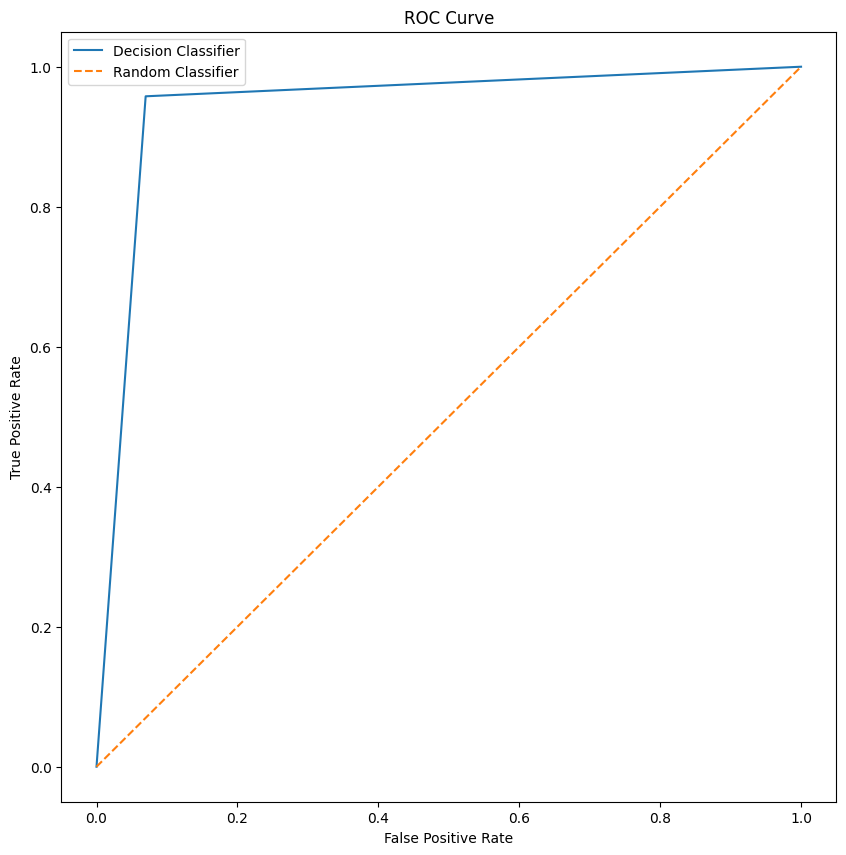

In [32]:
plt.figure(figsize=(10,10))
plt.plot(false_positive_rate1,true_positive_rate1, label='Decision Classifier')
plt.plot([0,1],[0,1],linestyle='--',label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()